# Spinless, spinful and Nambu basis for orbitals
The same `Geometry` can generate a Hamiltonian in different internal bases:
- **spinless**: one degree of freedom per orbital, $c_i$
- **spinful**: an explicit spin-1/2 per orbital, $(c_{i\uparrow},c_{i\downarrow})$, selected with `has_spin=True` (the default)
- **Nambu/BdG**: a particle-hole doubled spinful basis $\Psi_i=(c_{i\uparrow},c_{i\downarrow},c^\dagger_{i\downarrow},-c^\dagger_{i\uparrow})$, needed to host superconducting pairing, turned on with `setup_nambu_spinor()`

The matrix size per site tells them apart: 1, 2 and 4 respectively.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import islands

In [2]:
g = geometry.honeycomb_lattice()

h_spinless = g.get_hamiltonian(has_spin=False)
h_spinful  = g.get_hamiltonian(has_spin=True)
h_nambu    = g.get_hamiltonian(has_spin=True)
h_nambu.setup_nambu_spinor() # promote to the Nambu/BdG basis (zero pairing so far)

for name,h in [("spinless",h_spinless),("spinful",h_spinful),("Nambu",h_nambu)]:
    print(f"{name:10s}  onsite block h(0,0,0) shape = {h.intra.shape}")

spinless    onsite block h(0,0,0) shape = (2, 2)
spinful     onsite block h(0,0,0) shape = (4, 4)
Nambu       onsite block h(0,0,0) shape = (8, 8)


### What the extra degrees of freedom do to the band structure
In the spinful basis an exchange field splits the two spin bands, and coloring each state by
$\langle S_z\rangle$ tells them apart. In the Nambu basis an s-wave pairing opens a gap at the
Fermi energy, and coloring each state by its electron weight tells the electron copy of the bands
from the hole copy, with the two mixed only at the gap edges.

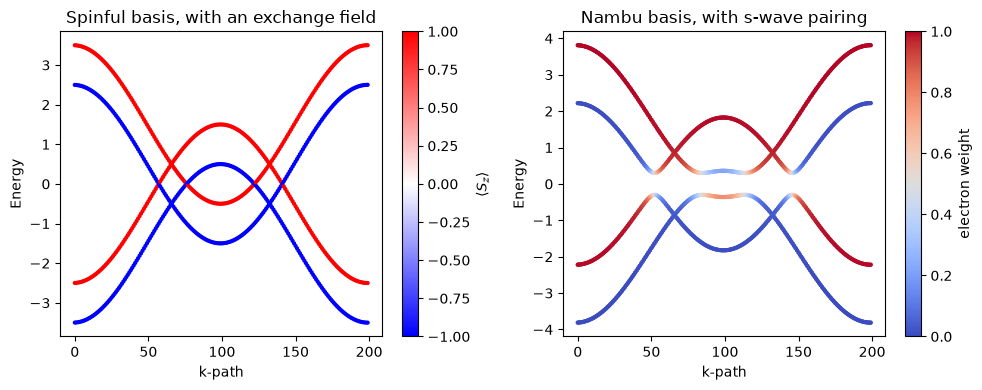

In [3]:
h1 = h_spinful.copy() # spinful honeycomb Hamiltonian
h1.add_exchange([0.,0.,0.5]) # exchange field along z, splits the two spin bands
(k1,e1,c1) = h1.get_bands(operator="sz",nk=200) # bands and <Sz> of each state

h2 = g.get_hamiltonian(has_spin=True) # spinful honeycomb Hamiltonian
h2.add_onsite(0.8) # move the Dirac points away from the Fermi energy
h2.setup_nambu_spinor() # Nambu basis
h2.add_swave(0.3) # s-wave pairing
(k2,e2,c2) = h2.get_bands(operator="electron",nk=200) # bands and electron weight of each state

fig,axs = plt.subplots(1,2,figsize=(10,4))
s = axs[0].scatter(k1,e1,c=c1,cmap="bwr",s=4,vmin=-1,vmax=1)
fig.colorbar(s,ax=axs[0],label="$\\langle S_z \\rangle$")
axs[0].set_title("Spinful basis, with an exchange field")
s = axs[1].scatter(k2,e2,c=c2,cmap="coolwarm",s=4,vmin=0,vmax=1)
fig.colorbar(s,ax=axs[1],label="electron weight")
axs[1].set_title("Nambu basis, with s-wave pairing")
for ax in axs: ax.set_xlabel("k-path") ; ax.set_ylabel("Energy")
plt.tight_layout()
plt.show()